In [2]:
import pandas as pd
from numba import jit, njit, prange
import numpy as np
from loaders import loader, load_references, load_strong

In [3]:
references = load_references()

strong = load_strong()
sept = loader('sept')
sept['str_i'] = [int(s) if s[0] != 'C' else -int(s[1:]) for s in sept['str']]

In [4]:
references.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       4797, 4798, 4799, 4800, 4801, 4802, 4803, 4804, 4805, 4806],
      dtype='int64', length=4807)

In [5]:
sept['referenced'] = False
for i, (start, end) in enumerate(references[['ostart', 'oend']].values):
    sept.loc[sept.index[start:end], 'referenced'] = True
    references.loc[i, 'text'] = ' '.join(sept.loc[sept.index[start:end], 'str_i'].astype(str))
sept['referenced'].value_counts()

referenced
False    461618
True      13782
Name: count, dtype: int64

In [6]:
referenced = sept.query('referenced')
not_referenced = sept.query('~referenced')

In [7]:
# variable names from ChatGPT, apologies
@njit(parallel=True)
def get_zscores(referenced_str, not_referenced_str, all_words, a0):
    zscores = np.empty(all_words.shape, dtype=float)
    total_len = len(referenced_str) + len(not_referenced_str)
    for i in prange(len(all_words)):
        word = all_words[i]
        c1 = (referenced_str == word).sum()
        c2 = (not_referenced_str == word).sum()
        fw = c1 + c2
        aw = fw/total_len * a0
        p1 = (c1 + aw) / (len(referenced_str) + a0 - fw)
        p2 = (c2 + aw) / (len(not_referenced_str) + a0 - fw)
        logodds = np.log(p1 / (1 - p1)) - np.log(p2 / (1 - p2))
        variance = 1 / (c1 + aw) + 1 / (c2 + aw)
        zscores[i] = logodds / np.sqrt(variance)
    zscores[np.isnan(zscores)] = 0
    return zscores

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(references['text'])
all_words = vectorizer.get_feature_names_out().astype(int)

In [ ]:
'''params = pd.DataFrame(columns=['a0', 'n', 'k', 's'], dtype=int)
for a0 in [10, 50, 100, 500, 1000]:
    print(a0)
    scores = get_zscores(referenced['str_i'].values, not_referenced['str_i'].values, all_words, a0)
    sort_idx = np.argsort(scores)
    for n_features in [5, 10, 50, 100, 614]:
        to_use = sort_idx[-n_features:]
        features = X[:, to_use]
        for k in range(2, 8):
            kmeans = KMeans(n_clusters=k)
            params.loc[len(params)] = [a0, n_features, k, silhouette_score(features, kmeans.fit_predict(features))]'''

In [ ]:
import matplotlib.pyplot as plt

NameError: name 'params' is not defined

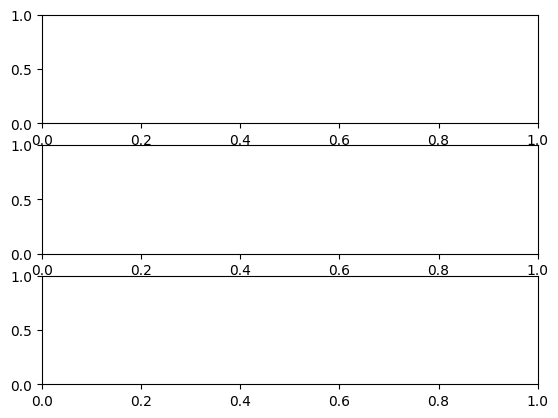

In [ ]:
'''fig, axes = plt.subplots(nrows=3)
for i, param in enumerate(['a0', 'k', 'n']):
    params.groupby(param)['s'].agg('mean').sort_index().plot.bar(ax=axes[i])
fig.set_size_inches(8, 10)
plt.tight_layout()'''

In [ ]:
#params['s'].max()

In [ ]:
scores = get_zscores(referenced['str_i'].values, not_referenced['str_i'].values, all_words, 10)
sort_idx = np.argsort(scores)
to_use = sort_idx[-5:]
features = X[:, to_use]
k = 3
kmeans = KMeans(n_clusters=k)
references['cluster'] = kmeans.fit_predict(features)

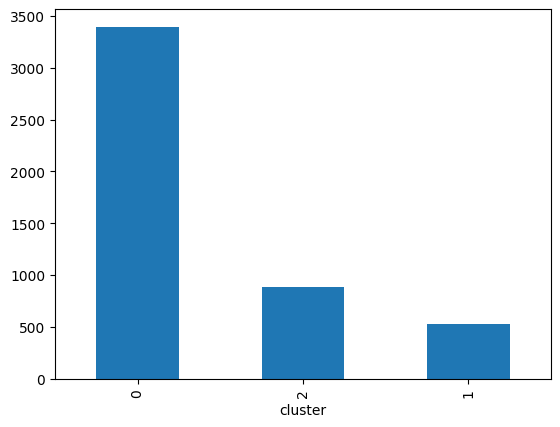

In [ ]:
references['cluster'].value_counts().plot.bar();

In [ ]:
strong.loc[all_words[to_use].astype(str)]

,original,def
str,,
1565,ἐκεῖνος,"he, it, the other (same), selfsame, that (same..."
3962,πατήρ,"father, parent"
2316,θεός,"X exceeding, God, god(-ly, -ward)"
4771,σύ,thou
1722,ἐν,"about, after, against, + almost, X altogether,..."


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
references[['x', 'y', 'z']] = pca.fit_transform(features)
references

,nstart,nlen,nend,ostart,olen,oend,text,cluster,x,y,z
0,475406,6,475412,14160,6,14166,5207 11 11 1080 3588 2464,0,-0.045493,-0.094540,-0.056589
1,475421,5,475426,28268,5,28273,2455 2532 3588 80 846,0,-0.045493,-0.094540,-0.056589
2,475429,5,475434,234063,5,234068,3588 5329 2532 3588 2196,0,-0.045493,-0.094540,-0.056589
3,475564,5,475569,247634,5,247639,2532 3588 80 846 1909,0,-0.045493,-0.094540,-0.056589
4,475565,5,475570,239039,5,239044,3588 80 846 1909 3588,0,-0.045493,-0.094540,-0.056589
...,...,...,...,...,...,...,...,...,...,...,...
4802,612901,5,612906,121551,5,121556,3588 1125 1722 3588 975,2,-0.158286,0.146708,0.020709
4803,612901,5,612906,138117,5,138122,3588 1125 1722 3588 975,2,-0.158286,0.146708,0.020709
4804,612901,6,612907,269120,6,269126,3588 1125 1722 3588 975 3778,2,-0.142605,0.113168,0.009963
4805,612901,5,612906,269190,5,269195,3588 1125 1722 3588 975,2,-0.158286,0.146708,0.020709


In [9]:
import pickle
with open("./pickles/clustered_references.pickle", "wb") as f:
    pickle.dump(references, f)